# Data preparation - Feature Engineering
Created by Guillermo Arredondo Renero

Creation date: May 4, 2026  
Last updated: May 5, 2026

**Main objective**: Realize feature engineering over interim data (cleaned data) to empower models in next stage. **Only for binary classification of default clients**

In [37]:
# ---------------------------- Libraries
## Directories
import os
## Data manipulation
import pandas as pd
import numpy as np

## Visualizations
import matplotlib.pyplot as plt
import seaborn as sns
import sidetable

# Extras
import warnings
warnings.filterwarnings('ignore')

# Transformation
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer

In [38]:
# ---------------------------- Directories
# Get main directory
CURRENT_DIR = os.getcwd()
MAIN_DIR = os.path.dirname(CURRENT_DIR)
INTERIM_DIR = os.path.join(MAIN_DIR, 'data', 'interim')
PROCESSED_DIR = os.path.join(MAIN_DIR, 'data', 'processed')
os.makedirs(PROCESSED_DIR, exist_ok=True)

## Data loading

In [39]:
df = pd.read_csv(os.path.join(INTERIM_DIR, 'credit_dataset_cleaned.csv'))

In [40]:
original_features = df.columns

## Transformations

### Categorical variables

Dado que no son muchas categorías para las variables categóricas no tenemos problema en usar One-Hot Encoding.  
Nótese que crearemos las variables dummy y eliminaremos la categórica ordinal, sin embargo, pudieramos usar la variable en forma ordinal para árboles de decisión de forma óptima. Dado que planeamos usar más que modelos de árboles y por simplicidad de código, usaremos la códificos OHE para todos los algoritmos por igual.

*Nota:* aquí podría usarse una categorización por medio de WOE para generar agrupaciones de categorías similares o para categorizar (a través de bins) las variables continuas.

In [41]:
# Get Female dummy variable
df['Female'] = df['SEX'] - 1

# Replace marriage and education with mapping
education_map = {1: 'Graduate', 2: 'University', 3: 'High School', 4: 'Others'}
marriage_map = {1: 'Married', 2: 'Single', 3: 'Others'}
df['EDUCATION'] = df['EDUCATION'].map(education_map)
df['MARRIAGE'] = df['MARRIAGE'].map(marriage_map)

# Create One Hot Encodings for MARRIAGE and EDUCATION
df = pd.concat(
    [
        df,
        pd.get_dummies(df.MARRIAGE, prefix='MARRIAGE').astype(int),
        pd.get_dummies(df.EDUCATION, prefix='EDUCATION').astype(int)
    ],
    axis=1
)

df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,PAY_AMT6,default_payment_next_month,Female,MARRIAGE_Married,MARRIAGE_Others,MARRIAGE_Single,EDUCATION_Graduate,EDUCATION_High School,EDUCATION_Others,EDUCATION_University
0,20000,2,University,Married,24,3,3,-1,-1,-1,...,0,1,1,1,0,0,0,0,0,1
1,120000,2,University,Single,26,-1,3,1,1,1,...,2000,1,1,0,0,1,0,0,0,1
2,90000,2,University,Single,34,1,1,1,1,1,...,5000,0,1,0,0,1,0,0,0,1
3,50000,2,University,Married,37,1,1,1,1,1,...,1000,0,1,1,0,0,0,0,0,1
4,50000,1,University,Married,57,-1,1,-1,1,1,...,679,0,0,1,0,0,0,0,0,1


In [42]:
# Drop original MARRIAGE and EDUCATION columns
df.drop(['MARRIAGE', 'EDUCATION'], axis=1, inplace=True)

### New variables

In [43]:
bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
pay_amt_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
pay_cols = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

# Calculate credit utilization (most recent bill amount / credit limit) - all of them 
    # What happens if negative? -> i guess its something relevant but idk if should be clipped to zero?
for i, col in enumerate(bill_cols, start=1):
    df[f'util_{i}'] = df[f'BILL_AMT{i}'] / (df['LIMIT_BAL'] + 1)  # Avoid division by zero

# Payment ratio (how much of the bill was paid)
    # Problem bill can be negative -> no positive bill = fully paid (refund or overpaid?)
for i, col in enumerate(pay_amt_cols, start=1):
    df[f'pay_ratio_{i}'] = np.where(
        df[f'BILL_AMT{i}'] > 0,
        df[f'PAY_AMT{i}'] / (df[f'BILL_AMT{i}'] + 1),
        1  
    )

# Remaining balance after payment
for i, col in enumerate(pay_amt_cols, start=1):
    df[f'remaining_bal_{i}'] = df[f'BILL_AMT{i}'] - df[f'PAY_AMT{i}']

# Calculate average monthly bill and payment
df['avg_monthly_bill'] = df[bill_cols].mean(axis=1)
df['avg_monthly_payment'] = df[pay_amt_cols].mean(axis=1)

# Create a feature: maximum payment delay across 6 months
df['max_payment_delay'] = df[pay_cols].max(axis=1)
df['has_any_delay'] = (df['max_payment_delay'] > 0).astype(int)

# Number of delayed months
df['n_months_delayed']= (df[pay_cols] > 0).sum(axis=1)
df['severe_delay_count'] = (df[pay_cols] >= 2).sum(axis=1)  # Count months with 2+ month delays
# df['has_severe_delay'] = (df['severe_delay_count'] > 0).astype(int)  # indicator

# Bill trend
df['bill_trend'] = df[bill_cols[0]] - df[bill_cols[-1]]

# Payment Consistency (Volatility) an coefficient of variation could be interesting as well
df['payment_volatility'] = df[pay_amt_cols].std(axis=1)
df['payment_cv'] = df['payment_volatility'] / (df['avg_monthly_payment'] + 1e3)  # Avoid division by zero
df['recent_payment_below_avg'] = (df[pay_amt_cols[0]] < df['avg_monthly_payment']).astype(int)

# # 11. Log Transformations for Highly Skewed Features (avoid log(0)) -> prefered RobustScaler for skewed data
# # Only apply to features with minimum value > 0 or handle zeros separately
# df['log_limit_bal'] = np.log1p(df['LIMIT_BAL'])  # log1p handles zeros
# df['log_bill_amt1'] = np.log1p(df['BILL_AMT1'])
# df['log_pay_amt1'] = np.log1p(df['PAY_AMT1'])
# df['log_avg_monthly_bill'] = np.log1p(df['avg_monthly_bill'])
# df['log_avg_monthly_payment'] = np.log1p(df['avg_monthly_payment'])
# df['log_total_billed_6m'] = np.log1p(df['total_billed_6m'])

# Total bill and payment amounts -> net debt
df['total_bill'] = df[bill_cols].sum(axis=1)
df['total_payment'] = df[pay_amt_cols].sum(axis=1)
df['net_debt'] = df['total_bill'] - df['total_payment']

# Overall utilization
df['overall_util'] = df['total_bill'] / (df['LIMIT_BAL'] + 1e3)  # Avoid division by zero

# Zero count -> bills = no use: pay = no payment
df['bill_zero_count'] = (df[bill_cols] == 0).sum(axis=1)
df['pay_zero_count'] = (df[pay_amt_cols] == 0).sum(axis=1)

# df['age_group'] = pd.cut(df['AGE'], bins=[20, 30, 40, 50, 80],
#                           labels=['20s','30s','40s','50+'])
# df.drop('AGE', axis=1, inplace=True)

In [44]:
# Display new features created
new_features = [col for col in df.columns if col not in original_features]

print("="*80)
print("FEATURE ENGINEERING SUMMARY")
print("="*80)
print(f"\nOriginal features: {len(pd.read_csv(os.path.join(INTERIM_DIR, 'credit_dataset_cleaned.csv')).columns)}")
print(f"New features created: {len(new_features)}")
print(f"Total features: {len(df.columns)}")
print(f"\n📊 NEW FEATURES ({len(new_features)} total):")
print("-" * 80)

print("\n" + "="*80)
print("Feature Statistics:")
print("="*80)
print(f"\nFeature with highest correlation to target (excluding original PAY_ features):")
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_with_target = df[numeric_cols].corr()['default_payment_next_month'].sort_values(ascending=False)
# Show top 10 new features by correlation
new_feature_corrs = corr_with_target[[f for f in corr_with_target.index if f in new_features and f != 'default_payment_next_month']]
print(new_feature_corrs.head(10))
print("\n" + "="*80)
df[new_features].describe()

FEATURE ENGINEERING SUMMARY

Original features: 24
New features created: 42
Total features: 64

📊 NEW FEATURES (42 total):
--------------------------------------------------------------------------------

Feature Statistics:

Feature with highest correlation to target (excluding original PAY_ features):
severe_delay_count    0.399075
max_payment_delay     0.313534
pay_zero_count        0.165532
util_6                0.123751
util_5                0.120251
util_4                0.117456
overall_util          0.114040
util_3                0.104794
util_2                0.099541
n_months_delayed      0.095439
Name: default_payment_next_month, dtype: float64



,Female,MARRIAGE_Married,MARRIAGE_Others,MARRIAGE_Single,EDUCATION_Graduate,EDUCATION_High School,EDUCATION_Others,EDUCATION_University,util_1,util_2,...,bill_trend,payment_volatility,payment_cv,recent_payment_below_avg,total_bill,total_payment,net_debt,overall_util,bill_zero_count,pay_zero_count
count,29601.000000,29601.000000,29601.000000,29601.000000,29601.000000,29601.000000,29601.000000,29601.000000,29601.000000,29601.000000,...,29601.000000,29601.000000,29601.000000,29601.000000,2.960100e+04,2.960100e+04,2.960100e+04,29601.000000,29601.000000,29601.000000
mean,0.603189,0.455289,0.010743,0.533968,0.357454,0.164623,0.004155,0.473768,0.422332,0.409984,...,12098.982197,5775.480267,0.596577,0.420830,2.689194e+05,3.154778e+04,2.373716e+05,2.193041,0.600588,1.228945
std,0.489244,0.498005,0.103091,0.498853,0.479258,0.370846,0.064328,0.499320,0.410376,0.403592,...,43547.759517,15002.807442,0.498209,0.493701,3.787821e+05,6.081785e+04,3.624624e+05,2.064562,1.441433,1.717039
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.619890,-1.395512,...,-428791.000000,0.000000,0.000000,0.000000,-3.362590e+05,0.000000e+00,-2.671514e+06,-1.368176,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.021820,0.018294,...,-2988.000000,615.337766,0.236444,0.000000,2.856800e+04,6.689000e+03,4.463000e+03,0.177900,0.000000,0.000000
50%,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.311639,0.293934,...,886.000000,1412.802841,0.467018,0.000000,1.254760e+05,1.435300e+04,1.014450e+05,1.678619,0.000000,0.000000
75%,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.827802,0.804487,...,19553.000000,4114.441282,0.798148,1.000000,3.412680e+05,3.342400e+04,3.035990e+05,4.055081,0.000000,2.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,6.454977,6.380181,...,708323.000000,650098.338820,2.391297,1.000000,5.263883e+06,3.764066e+06,4.116080e+06,30.653190,6.000000,6.000000


### Data partition

In [45]:
BINARY_DIR = os.path.join(PROCESSED_DIR, "binary_classification")
os.makedirs(BINARY_DIR, exist_ok=True)

In [46]:
# Create directories for train, test and val sets
for split in ['train', 'test', 'val']:
    os.makedirs(os.path.join(BINARY_DIR, split), exist_ok=True)

In [47]:
# Split data into features and target
X = df.drop(columns=['default_payment_next_month'])
y = df['default_payment_next_month']

# Split into train (65%), test (20%), and validation (15%) sets
# Split off test (20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y , test_size = 0.2, random_state=65, stratify=y)

# Second split: split 80 into 65-and 15 (15% = 0.15/0.8 = 0.1875 of the original data)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1875, random_state=65, stratify=y_train_val
)

print("="*80)
print("DATA SPLIT SUMMARY")
print("="*80)
print(f"\nTraining Set: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"  - Default rate: {y_train.mean()*100:.2f}%")
print(f"Validation Set: {len(X_val)} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"  - Default rate: {y_val.mean()*100:.2f}%")
print(f"Test Set: {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"  - Default rate: {y_test.mean()*100:.2f}%")
print(f"\nTotal Samples: {len(X)}")
print(f"Total Features: {X.shape[1]}")
print(f"\nClass Balance Maintained:")
print(f"  Training: {y_train.value_counts().to_dict()}")
print(f"  Validation: {y_val.value_counts().to_dict()}")
print(f"  Test: {y_test.value_counts().to_dict()}")
print("="*80)

DATA SPLIT SUMMARY

Training Set: 19240 samples (65.0%)
  - Default rate: 22.31%
Validation Set: 4440 samples (15.0%)
  - Default rate: 22.32%
Test Set: 5921 samples (20.0%)
  - Default rate: 22.31%

Total Samples: 29601
Total Features: 63

Class Balance Maintained:
  Training: {0: 14947, 1: 4293}
  Validation: {0: 3449, 1: 991}
  Test: {0: 4600, 1: 1321}


### Scaling & Transformations

Como se observó en el análisis exploratorio, muchas de estas variables tienen un comportamiento muy sesgado con distribuciones con cola muy pesadas (exponenciales/poisson) por lo que no es recomendable utilizar StandardScaler por la sensibilidad a los outliers. En su lugar, prefiero usar un RobustScaler que utiliza el rango intercuartílico para reescalar. 

In [48]:
# Identify features to scale
# Binary/categorical features should NOT be scaled
binary_features = [col for col in X.columns if df[col].nunique() == 2]
categorical_features = [col for col in X.columns if col.startswith('MARRIAGE') or col.startswith('EDUCATION') or col.startswith('age_group') or col == 'max_payment_delay'] + \
    [f'PAY_{i}' for i in range(1, 7)] + [col for col in X.columns if X[col].nunique() <= 8]
non_scaled_features = binary_features + categorical_features

# Features to scale: all numeric features except categorical/binary
features_to_scale = [col for col in X.select_dtypes(include=[np.number]).columns 
                     if col not in non_scaled_features]

print(f"Features to scale: {len(features_to_scale)}")
print(f"Binary features (not scaled): {len(binary_features)}")
print(f"Categorical features (not scaled): {len(categorical_features)}")
print(f"\nSample of features to scale: {features_to_scale}")

Features to scale: 41
Binary features (not scaled): 11
Categorical features (not scaled): 29

Sample of features to scale: ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'util_1', 'util_2', 'util_3', 'util_4', 'util_5', 'util_6', 'pay_ratio_1', 'pay_ratio_2', 'pay_ratio_3', 'pay_ratio_4', 'pay_ratio_5', 'pay_ratio_6', 'remaining_bal_1', 'remaining_bal_2', 'remaining_bal_3', 'remaining_bal_4', 'remaining_bal_5', 'remaining_bal_6', 'avg_monthly_bill', 'avg_monthly_payment', 'bill_trend', 'payment_volatility', 'payment_cv', 'total_bill', 'total_payment', 'net_debt', 'overall_util']


In [49]:
# Apply RobustScaler to features (better than StandardScaler for skewed distributions with outliers)
preprocessor = ColumnTransformer(transformers=[
    ('robust_scaler', RobustScaler(), features_to_scale)
], remainder='passthrough')

# Fit and transform the training data, then transform validation and test sets
X_train_scaled = preprocessor.fit_transform(X_train)
X_val_scaled = preprocessor.transform(X_val)
X_test_scaled = preprocessor.transform(X_test)

# Get the correct feature names in the transformed order
feature_names_out = preprocessor.get_feature_names_out()
# Remove the prefixes ('robust_scaler__' or 'remainder__') to get original names
columns_after_scaling = [name.split('__')[1] for name in feature_names_out]

# Create DataFrames with correct column order
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=columns_after_scaling, index=X_train.index)
X_val_scaled_df = pd.DataFrame(X_val_scaled, columns=columns_after_scaling, index=X_val.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=columns_after_scaling, index=X_test.index)

assert not X_train_scaled_df[features_to_scale].astype('float64').isnull().any().any(), 'Transform went wrong'
assert not X_val_scaled_df[features_to_scale].astype('float64').isnull().any().any(), 'Transform went wrong'
assert not X_test_scaled_df[features_to_scale].astype('float64').isnull().any().any(), 'Transform went wrong'

# Verify scaling by comparing before and after
print("\n" + "="*80)
print("SCALING VERIFICATION - RobustScaler (IQR-based)")
print("="*80)

print("\n📊 TRAINING SET - Before Scaling:")
print(X_train.shape)
print(X_train[features_to_scale].describe().loc[['count', 'mean', 'std', 'min', 'max']].round(3))

print("\n📊 TRAINING SET - After Scaling:")
print(X_train_scaled_df.shape)
print(X_train_scaled_df[features_to_scale].astype('float64').describe().loc[['count', 'mean', 'std', 'min', 'max']].round(3))

print("\n" + "-"*80)
print("\n📊 VALIDATION SET - Before Scaling:")
print(X_val.shape)
print(X_val[features_to_scale].describe().loc[['count', 'mean', 'std', 'min', 'max']].round(3))

print("\n📊 VALIDATION SET - After Scaling:")
print(X_val_scaled_df.shape)
print(X_val_scaled_df[features_to_scale].astype('float64').describe().loc[['count', 'mean', 'std', 'min', 'max']].round(3))

print("\n" + "-"*80)
print("\n📊 TEST SET - Before Scaling:")
print(X_test.shape)
print(X_test[features_to_scale].describe().loc[['count', 'mean', 'std', 'min', 'max']].round(3))

print("\n📊 TEST SET - After Scaling:")
print(X_test_scaled_df.shape)
print(X_test_scaled_df[features_to_scale].astype('float64').describe().loc[['count', 'mean', 'std', 'min', 'max']].round(3))

print("\n" + "="*80)


SCALING VERIFICATION - RobustScaler (IQR-based)

📊 TRAINING SET - Before Scaling:
(19240, 63)
        LIMIT_BAL        AGE   BILL_AMT1   BILL_AMT2    BILL_AMT3   BILL_AMT4  \
count   19240.000  19240.000   19240.000   19240.000    19240.000   19240.000   
mean   168609.979     35.427   50976.949   48994.452    46992.544   43314.028   
std    131072.384      9.195   73207.414   70616.022    68946.805   63605.965   
min     10000.000     21.000 -165580.000  -67526.000   -61506.000  -81334.000   
max    800000.000     75.000  746814.000  743970.000  1664089.000  565669.000   

        BILL_AMT5   BILL_AMT6    PAY_AMT1     PAY_AMT2  ...  remaining_bal_6  \
count   19240.000   19240.000   19240.000    19240.000  ...        19240.000   
mean    40453.217   39148.430    5725.448     5931.620  ...        33863.505   
std     60604.725   59589.804   17358.421    24134.139  ...        60247.570   
min    -81334.000 -339603.000       0.000        0.000  ...      -684896.000   
max    587067.000 

### Save processed datasets

In [50]:
# Create directories for train, test and val sets
for split in ['train', 'test', 'val']:
    os.makedirs(os.path.join(BINARY_DIR, split), exist_ok=True)

# Save non scaled data
# Combine X and y for each set
train_data = pd.concat([X_train, y_train], axis=1)
val_data = pd.concat([X_val, y_val], axis=1)
test_data = pd.concat([X_test, y_test], axis=1)

# Save datasets
train_data.to_csv(os.path.join(BINARY_DIR, 'train', 'train_data.csv'), index=False)
val_data.to_csv(os.path.join(BINARY_DIR, 'val', 'val_data.csv'), index=False)
test_data.to_csv(os.path.join(BINARY_DIR, 'test', 'test_data.csv'), index=False)

# Save scaled data
# Combine X and y for each set
train_data_scaled = pd.concat([X_train_scaled_df, y_train], axis=1)
val_data_scaled = pd.concat([X_val_scaled_df, y_val], axis=1)
test_data_scaled = pd.concat([X_test_scaled_df, y_test], axis=1)

# Save datasets
train_data_scaled.to_csv(os.path.join(BINARY_DIR, 'train', 'train_data_scaled.csv'), index=False)
val_data_scaled.to_csv(os.path.join(BINARY_DIR, 'val', 'val_data_scaled.csv'), index=False)
test_data_scaled.to_csv(os.path.join(BINARY_DIR, 'test', 'test_data_scaled.csv'), index=False)

# Also save feature names for reference
feature_names = pd.DataFrame({
    'feature_name': X.columns.tolist(),
    'feature_type': [
        'binary' if col in binary_features else 
        'categorical' if col in categorical_features else
        'numeric'
        for col in X.columns
    ]
})
feature_names.to_csv(os.path.join(BINARY_DIR, 'feature_names.csv'), index=False)

print("✅ Datasets saved successfully!")
print(f"\nFiles saved in: {BINARY_DIR}")
print(f"  • train_data.csv ({len(train_data)} rows, {len(train_data.columns)} columns)")
print(f"      • train_data_scaled.csv ({len(train_data_scaled)} rows, {len(train_data_scaled.columns)} columns)")
print(f"  • val_data.csv ({len(val_data)} rows, {len(val_data.columns)} columns)")
print(f"      • val_data_scaled.csv ({len(val_data_scaled)} rows, {len(val_data_scaled.columns)} columns)")
print(f"  • test_data.csv ({len(test_data)} rows, {len(test_data.columns)} columns)")
print(f"      • test_data_scaled.csv ({len(test_data_scaled)} rows, {len(test_data_scaled.columns)} columns)")
print(f"  • feature_names.csv (Feature metadata)")

# # Save scaler parameters for future predictions
# import pickle
# with open(os.path.join(BINARY_DIR, 'scaler.pkl'), 'wb') as f:
#     pickle.dump(scaler, f)
# print(f"  • scaler.pkl (RobustScaler for applying same transformation to new data)")

# print("\n" + "="*80)

✅ Datasets saved successfully!

Files saved in: c:\Users\Memit\OneDrive - INSTITUTO TECNOLOGICO AUTONOMO DE MEXICO\Documentos\AplicacionesTrabajo\Bluetab\default_credit_prediction\data\processed\binary_classification
  • train_data.csv (19240 rows, 64 columns)
      • train_data_scaled.csv (19240 rows, 64 columns)
  • val_data.csv (4440 rows, 64 columns)
      • val_data_scaled.csv (4440 rows, 64 columns)
  • test_data.csv (5921 rows, 64 columns)
      • test_data_scaled.csv (5921 rows, 64 columns)
  • feature_names.csv (Feature metadata)


## New features analysis

In [51]:
# Feature Engineering Final Analysis
print("="*80)
print("FEATURE ENGINEERING - FINAL ANALYSIS")
print("="*80)

# Correlation analysis for new features
numeric_df = train_data.select_dtypes(include=[np.number])
correlations = numeric_df.corr()['default_payment_next_month'].drop('default_payment_next_month').sort_values(ascending=False)

print("\n📊 TOP 15 MOST CORRELATED FEATURES WITH DEFAULT:")
print("-" * 80)
for i, (feat, corr) in enumerate(correlations.head(15).items(), 1):
    print(f"{i:2d}. {feat:40s} → {corr:+.4f}")

print("\n\n DIMENSIONALITY SUMMARY:")
print("-" * 80)
print(f"Original dataset features: {len(original_features) - 1}")
print(f"One-hot encoded categorical features: {len([c for c in X.columns if c.startswith('MARRIAGE_') or c.startswith('EDUCATION_')])}")
print(f"Engineered new features: {len(new_features)}")
print(f"Total features in model: {X.shape[1]}")
print(f"\nFeature composition:")
print(f"  • Binary indicators: {len(binary_features)}")
print(f"  • Categorical dummies: {len(categorical_features)}")
print(f"  • Scaled numeric: {len(features_to_scale)}")
print("="*80)

FEATURE ENGINEERING - FINAL ANALYSIS

📊 TOP 15 MOST CORRELATED FEATURES WITH DEFAULT:
--------------------------------------------------------------------------------
 1. severe_delay_count                       → +0.4006
 2. max_payment_delay                        → +0.3144
 3. PAY_1                                    → +0.2938
 4. PAY_2                                    → +0.2485
 5. PAY_3                                    → +0.2267
 6. PAY_4                                    → +0.2065
 7. PAY_5                                    → +0.1911
 8. PAY_6                                    → +0.1820
 9. pay_zero_count                           → +0.1734
10. util_6                                   → +0.1192
11. util_5                                   → +0.1156
12. util_4                                   → +0.1153
13. overall_util                             → +0.1120
14. util_3                                   → +0.1050
15. util_2                                   → +0.0993


 DIMEN

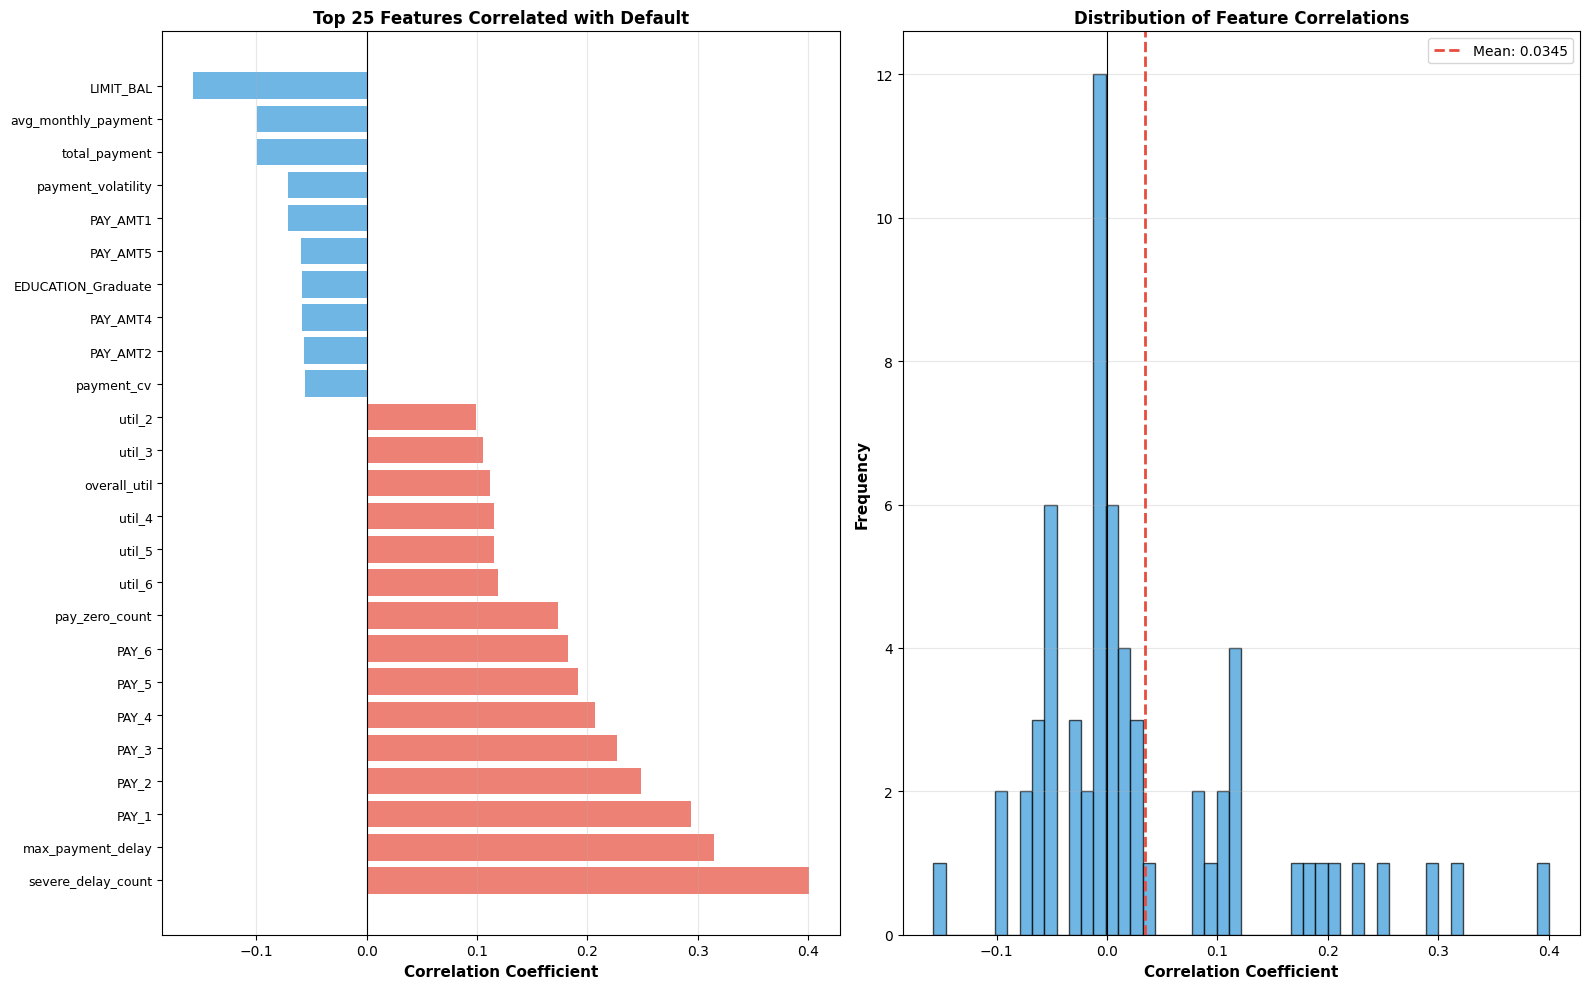


📊 CORRELATION STATISTICS:
  Mean correlation: +0.0345
  Median correlation: +0.0000
  Std dev: 0.1074
  Features with |r| > 0.15: 10
  Features with |r| > 0.10: 15
  Features with |r| > 0.05: 30


In [52]:
# Visualize feature correlations with target
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# Top positive and negative correlations
top_positive = correlations.head(15)
top_negative = correlations.tail(10)
top_combined = pd.concat([top_positive, top_negative])

# Color bars
colors = ['#e74c3c' if x > 0 else '#3498db' for x in top_combined.values]

axes[0].barh(range(len(top_combined)), top_combined.values, color=colors, alpha=0.7)
axes[0].set_yticks(range(len(top_combined)))
axes[0].set_yticklabels(top_combined.index, fontsize=9)
axes[0].set_xlabel('Correlation Coefficient', fontsize=11, fontweight='bold')
axes[0].set_title('Top 25 Features Correlated with Default', fontsize=12, fontweight='bold')
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
axes[0].grid(axis='x', alpha=0.3)

# Histogram of all correlations
axes[1].hist(correlations.values, bins=50, color='#3498db', alpha=0.7, edgecolor='black')
axes[1].axvline(x=correlations.mean(), color='#e74c3c', linestyle='--', linewidth=2, label=f'Mean: {correlations.mean():.4f}')
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
axes[1].set_xlabel('Correlation Coefficient', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[1].set_title('Distribution of Feature Correlations', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Statistics on correlations
print("\n📊 CORRELATION STATISTICS:")
print(f"  Mean correlation: {correlations.mean():+.4f}")
print(f"  Median correlation: {correlations.median():+.4f}")
print(f"  Std dev: {correlations.std():.4f}")
print(f"  Features with |r| > 0.15: {len(correlations[abs(correlations) > 0.15])}")
print(f"  Features with |r| > 0.10: {len(correlations[abs(correlations) > 0.10])}")
print(f"  Features with |r| > 0.05: {len(correlations[abs(correlations) > 0.05])}")